## Example plotting following [ASP Docs Section 8.4](https://stereopipeline.readthedocs.io/en/latest/examples/moc.html#mars-global-surveyor-moc-na) for Mars Global Surveyor (MGS) Mars Orbital Camera (MOC) Narrow Angle (NA)

Below are example `asp_plot` outputs following the processing in ASP Docs Mars MOC example [Section 8.4](https://stereopipeline.readthedocs.io/en/latest/examples/moc.html#mars-global-surveyor-moc-na).

Retrieve `.imq` files:

```bash
wget -O M0806047.imq \
   https://planetarydata.jpl.nasa.gov/img/data/mgs-m-moc-na_wa-2-sdp-l0-v1.0/mgsc_1068/m08060/m0806047.imq

wget -O R0701361.imq \
   https://planetarydata.jpl.nasa.gov/img/data/mgs-m-moc-na_wa-2-sdp-l0-v1.0/mgsc_1270/r07013/r0701361.imq
```

---

[Install ISIS](https://astrogeology.usgs.gov/docs/how-to-guides/environment-setup-and-maintenance/installing-isis-via-anaconda/#installing-isis) and pre-process the images for stereo:

```bash
ISIS> moc2isis f=M0806047.imq t=M0806047.cub
ISIS> moc2isis f=R0701361.imq t=R0701361.cub
ISIS> spiceinit from=M0806047.cub
ISIS> spiceinit from=R0701361.cub
ISIS> cam2map4stereo.py M0806047.cub R0701361.cub
```

---

Run stereo processing and point2dem:

```bash
parallel_stereo M0806047.map.cub R0701361.map.cub result/output

point2dem -r mars --stereographic --auto-proj-center result/output-PC.tif --errorimage result/output-PC.tif
```

## Full report

Example command for full stereo-processing report

In [1]:
directory = "~/Desktop/asp-plot-examples/mars_MOC_NA/"
stereo_directory = "result/"

In [2]:
!asp_plot \
  --directory $directory \
  --stereo_directory $stereo_directory \
  --subset_km 1 \
  --add_basemap False \
  --plot_icesat False \
  --plot_geometry False


Processing ASP files in /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/


No reference DEM found in log files. Please supply the reference DEM you used during stereo processing (or another reference DEM) if you would like to see some difference maps.



ASP DEM: /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/result/output-DEM.tif


Using map projection from DEM: EPSG:None

Figure saved to /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/tmp_asp_report_plots/00.png
Figure saved to /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/tmp_asp_report_plots/01.png
Figure saved to /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/tmp_asp_report_plots/02.png
Plotting DEM results. This can take a minute for large inputs.
Figure saved to /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/tmp_asp_report_plots/03.png
Figure saved to /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/tmp_asp_report_plots/04.png


Report saved to /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/result/asp_plot_report_m

### Full report with MOLA altimetry

To include MOLA altimetry comparison plots in the report, first request the data using `request_planetary_altimetry` (see the [MOLA Altimetry Comparison](#MOLA-Altimetry-Comparison) section below for details), then pass the downloaded CSV via `--altimetry_csv`:

In [3]:
mola_csv = f"{directory}/438125_mola/MolaPEDR_24N24N_263E263E_20260319T205257836_topo_csv.csv"

!asp_plot \
  --directory $directory \
  --stereo_directory $stereo_directory \
  --subset_km 1 \
  --add_basemap False \
  --plot_altimetry True \
  --altimetry_csv $mola_csv \
  --plot_geometry False \
  --report_filename ../../reports/MOC_NA-asp-plot-report.pdf


Processing ASP files in /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/


No reference DEM found in log files. Please supply the reference DEM you used during stereo processing (or another reference DEM) if you would like to see some difference maps.



ASP DEM: /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/result/output-DEM.tif


Using map projection from DEM: EPSG:None

Figure saved to /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/tmp_asp_report_plots/00.png
Figure saved to /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/tmp_asp_report_plots/01.png
Figure saved to /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/tmp_asp_report_plots/02.png
Plotting DEM results. This can take a minute for large inputs.
Figure saved to /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/tmp_asp_report_plots/03.png
Figure saved to /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/tmp_asp_report_plots/04.png

Detected planetary body: mars

Note: MOLA topography is referenced to the MOLA areoid. ASP

## Individual plots

Example modular usage of `asp_plot` for this example processing.

### Processing Parameters

In [4]:
%load_ext autoreload
%autoreload 2

from asp_plot.processing_parameters import ProcessingParameters

In [5]:
processing_parameters = ProcessingParameters(
    processing_directory=directory,
    stereo_directory=stereo_directory
)
processing_parameters_dict = processing_parameters.from_log_files()

print(f"Processed on: {processing_parameters_dict['processing_timestamp']}\n")

print(f"Reference DEM: {processing_parameters_dict['reference_dem']}\n")

print(f"Bundle adjustment ({processing_parameters_dict['bundle_adjust_run_time']}):\n")
print(processing_parameters_dict["bundle_adjust"])

print(f"\nStereo ({processing_parameters_dict['stereo_run_time']}):\n")
print(processing_parameters_dict["stereo"])

print(f"\nPoint2dem ({processing_parameters_dict['point2dem_run_time']}):\n")
print(processing_parameters_dict["point2dem"])

Processed on: 2025-10-31 11:54:20

Reference DEM: 

Bundle adjustment (N/A):

Bundle adjustment not run

Stereo (0 hours and 2 minutes):

stereo M0806047.map.cub R0701361.map.cub result/output --corr-seed-mode 1 --sgm-collar-size 0 --compute-point-cloud-center-only --threads 8

Point2dem (0 hours and 0 minutes):

point2dem -r mars --stereographic --auto-proj-center result/output-PC.tif --errorimage result/output-PC.tif


### Scene Plots

In [6]:
from asp_plot.scenes import ScenePlotter

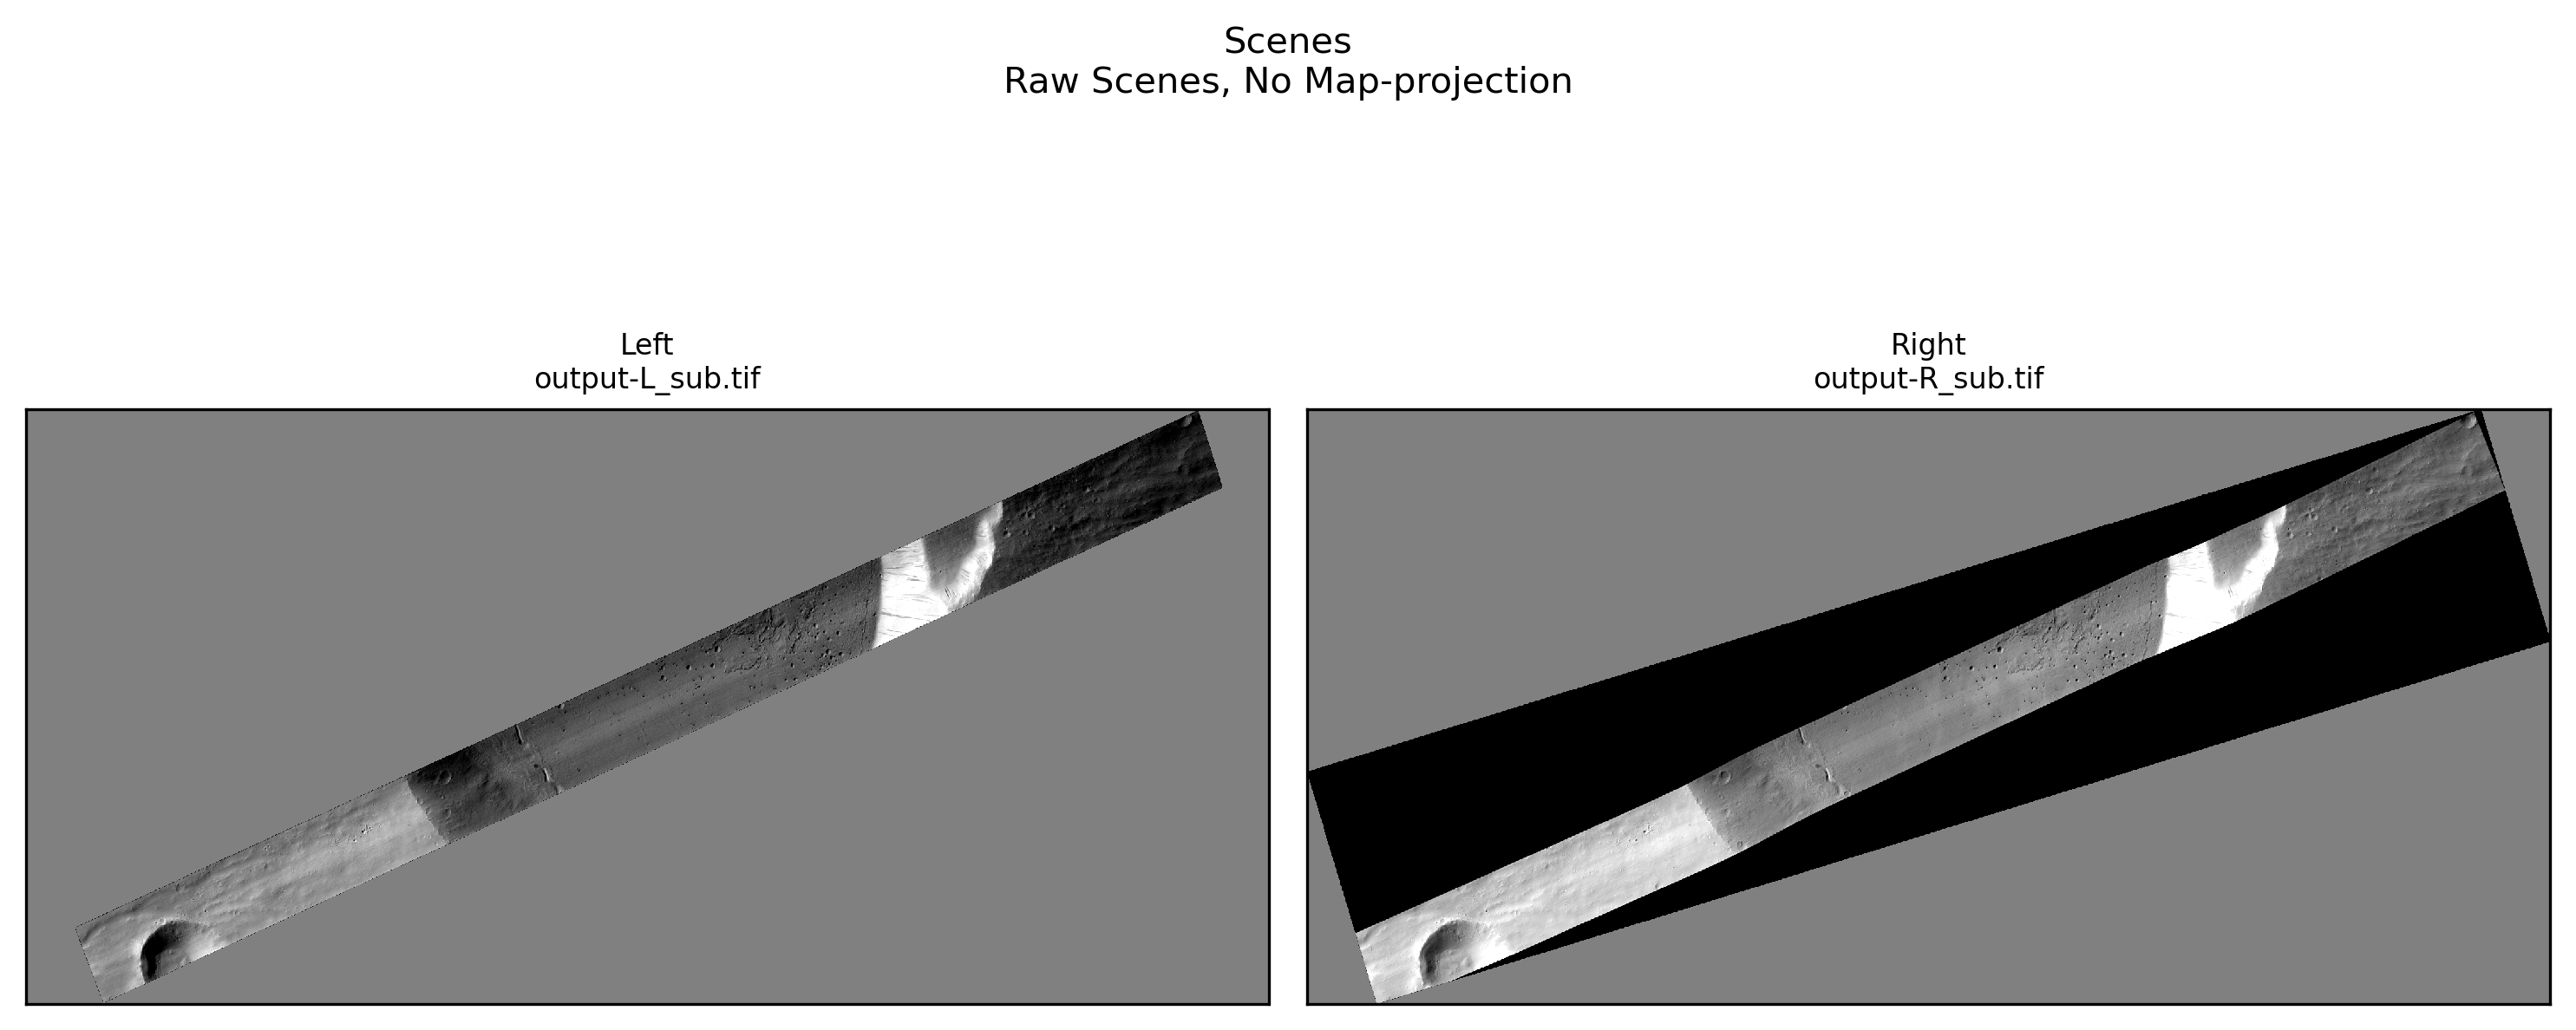

In [7]:
plotter = ScenePlotter(
  directory,
  stereo_directory,
  title="Scenes"
)

plotter.plot_scenes()

### Stereo Plots

In [8]:
from asp_plot.stereo import StereoPlotter

In [9]:
plotter = StereoPlotter(
  directory, 
  stereo_directory
)


No reference DEM found in log files. Please supply the reference DEM you used during stereo processing (or another reference DEM) if you would like to see some difference maps.





ASP DEM: /Users/ben/Desktop/asp-plot-examples/mars_MOC_NA/result/output-DEM.tif



/Users/ben/miniforge3/envs/asp_plot/lib/python3.14/site-packages/osgeo/gdal.py:606: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


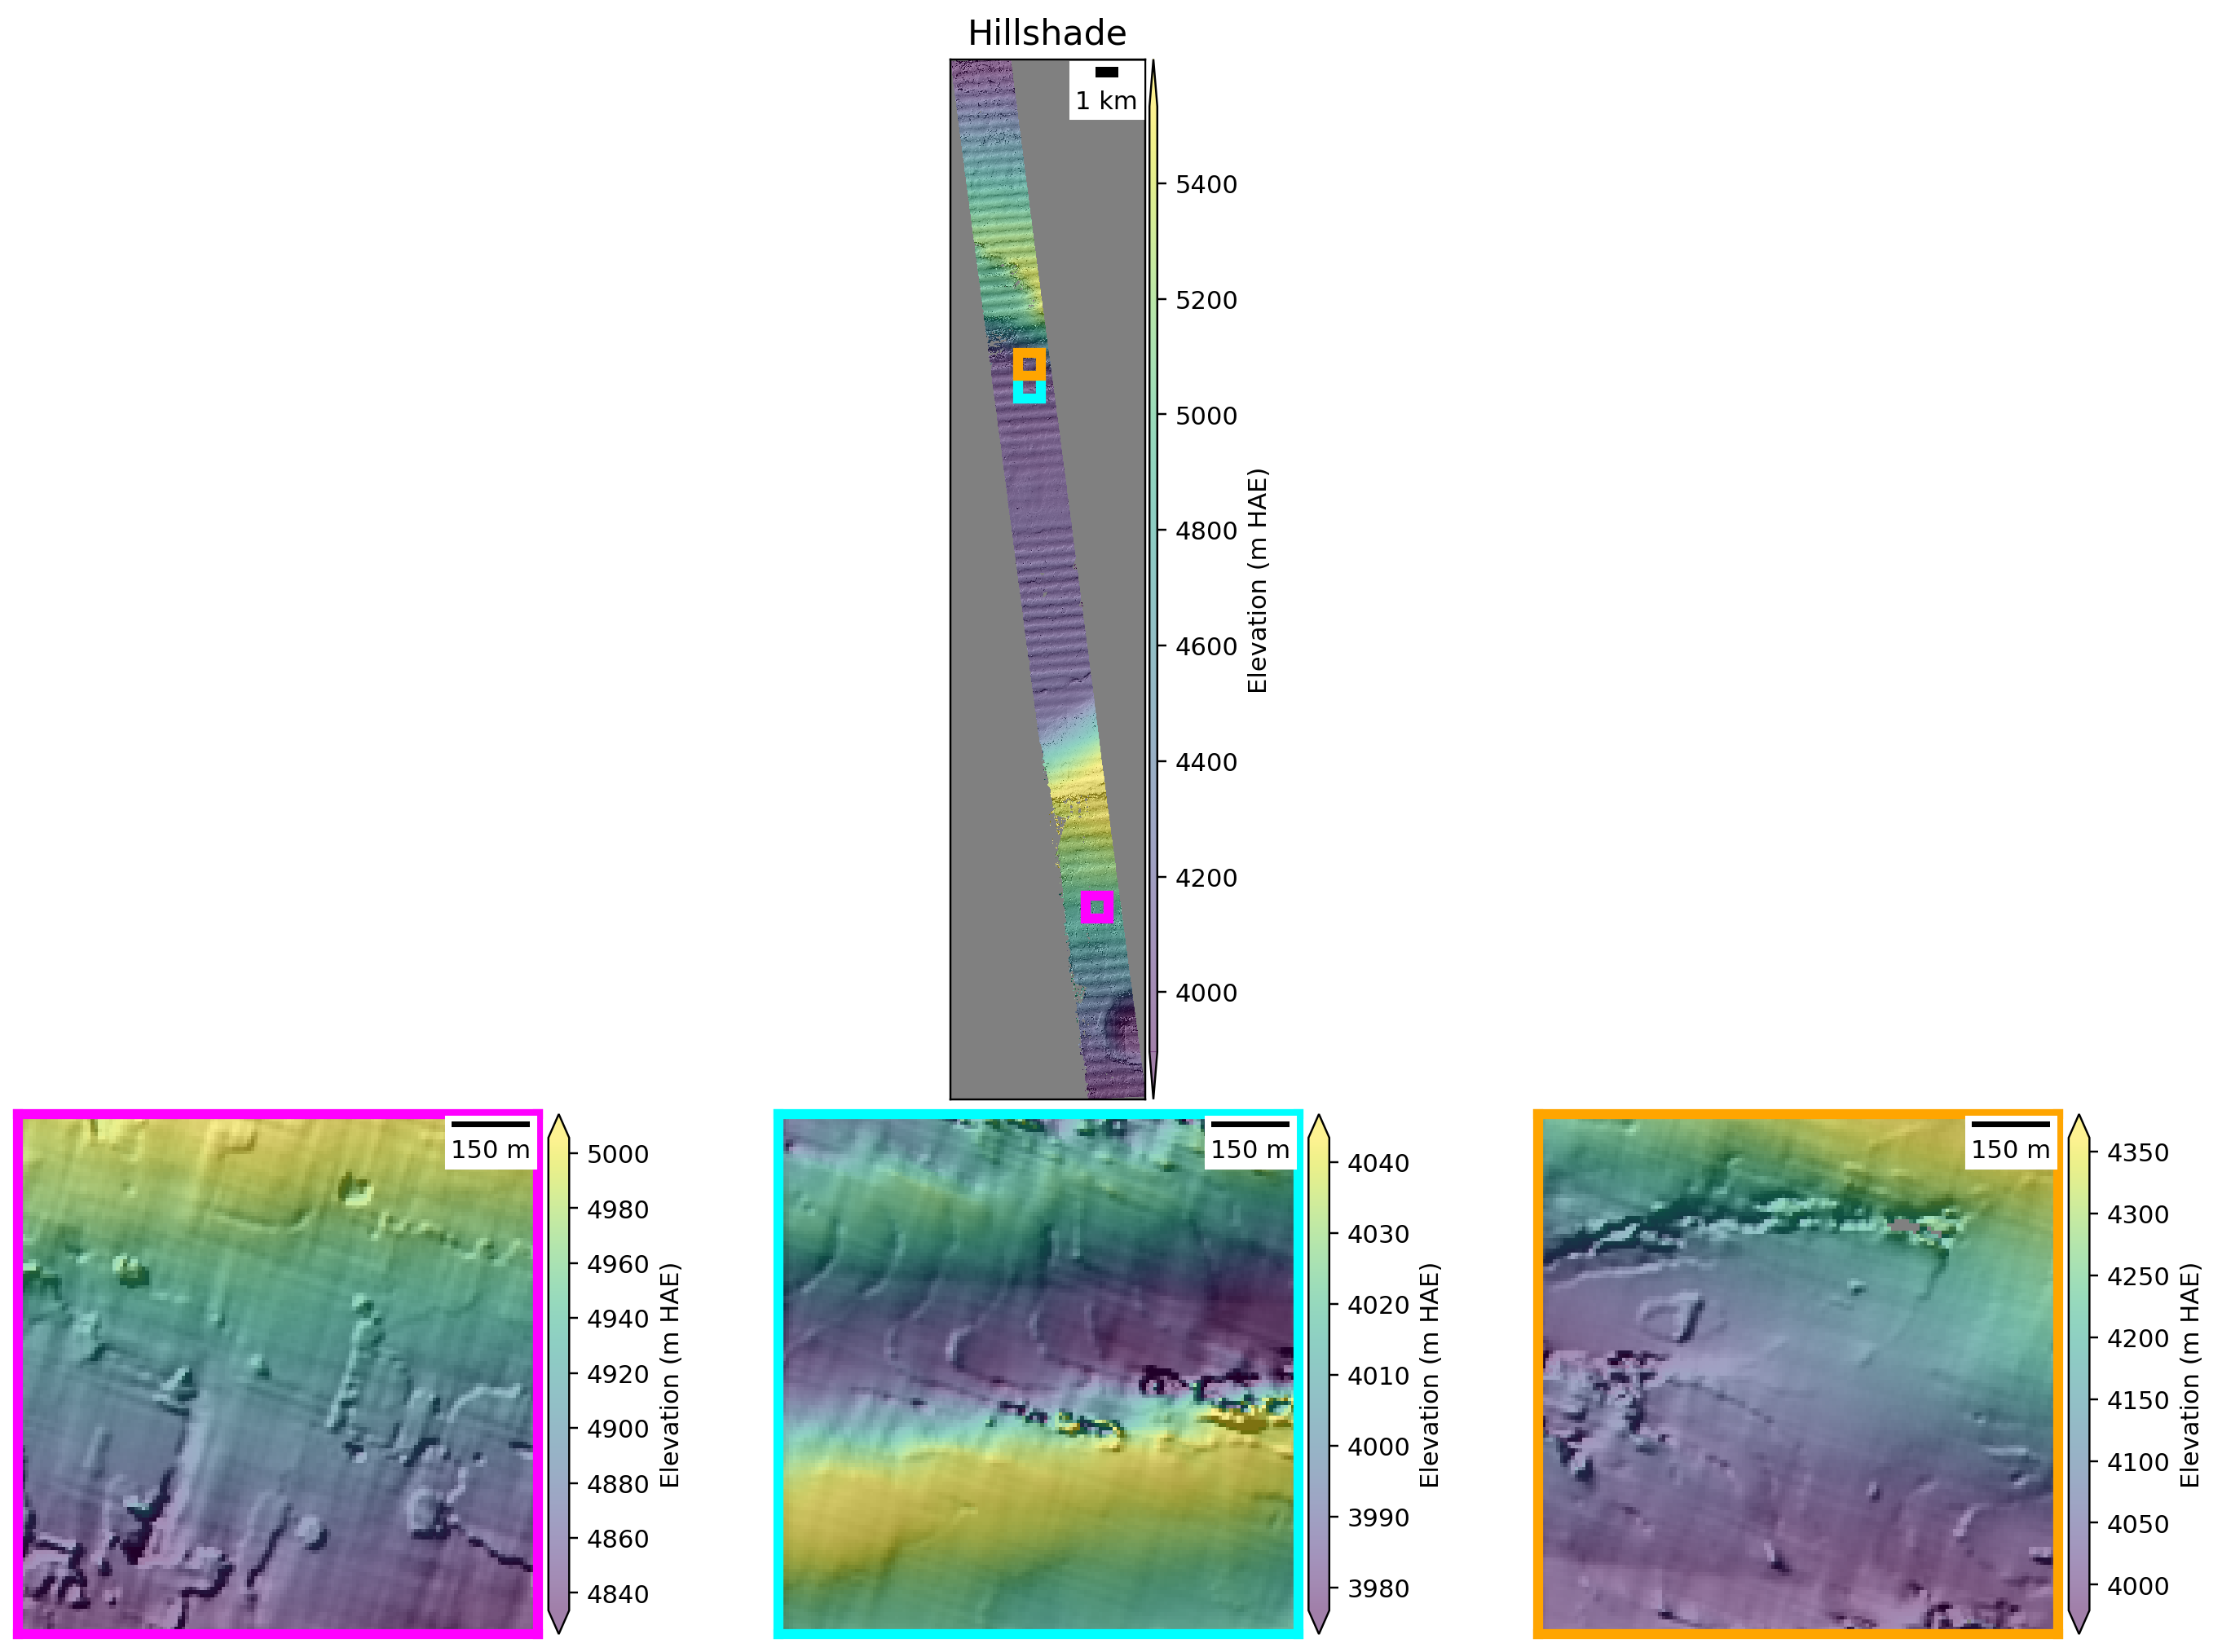

In [10]:
plotter.title = "Hillshade"

plotter.plot_detailed_hillshade()

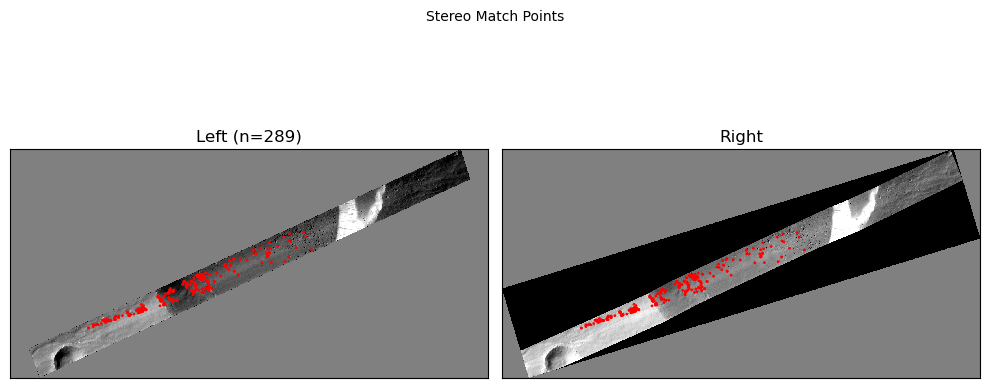

In [11]:
plotter.title="Stereo Match Points"

plotter.plot_match_points()

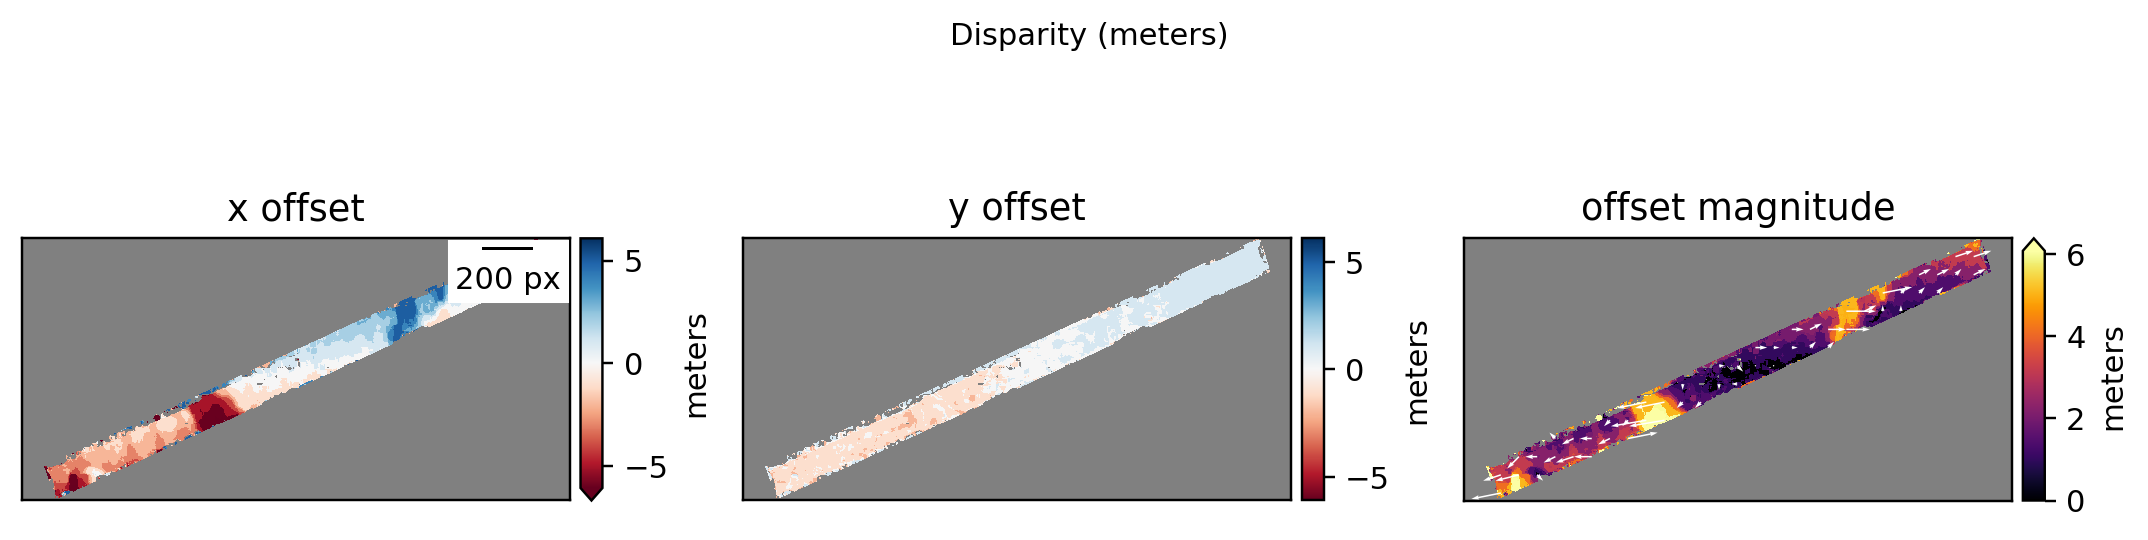

In [12]:
plotter.title = "Disparity (meters)"

plotter.plot_disparity(
  unit="meters",
  quiver=True,
)

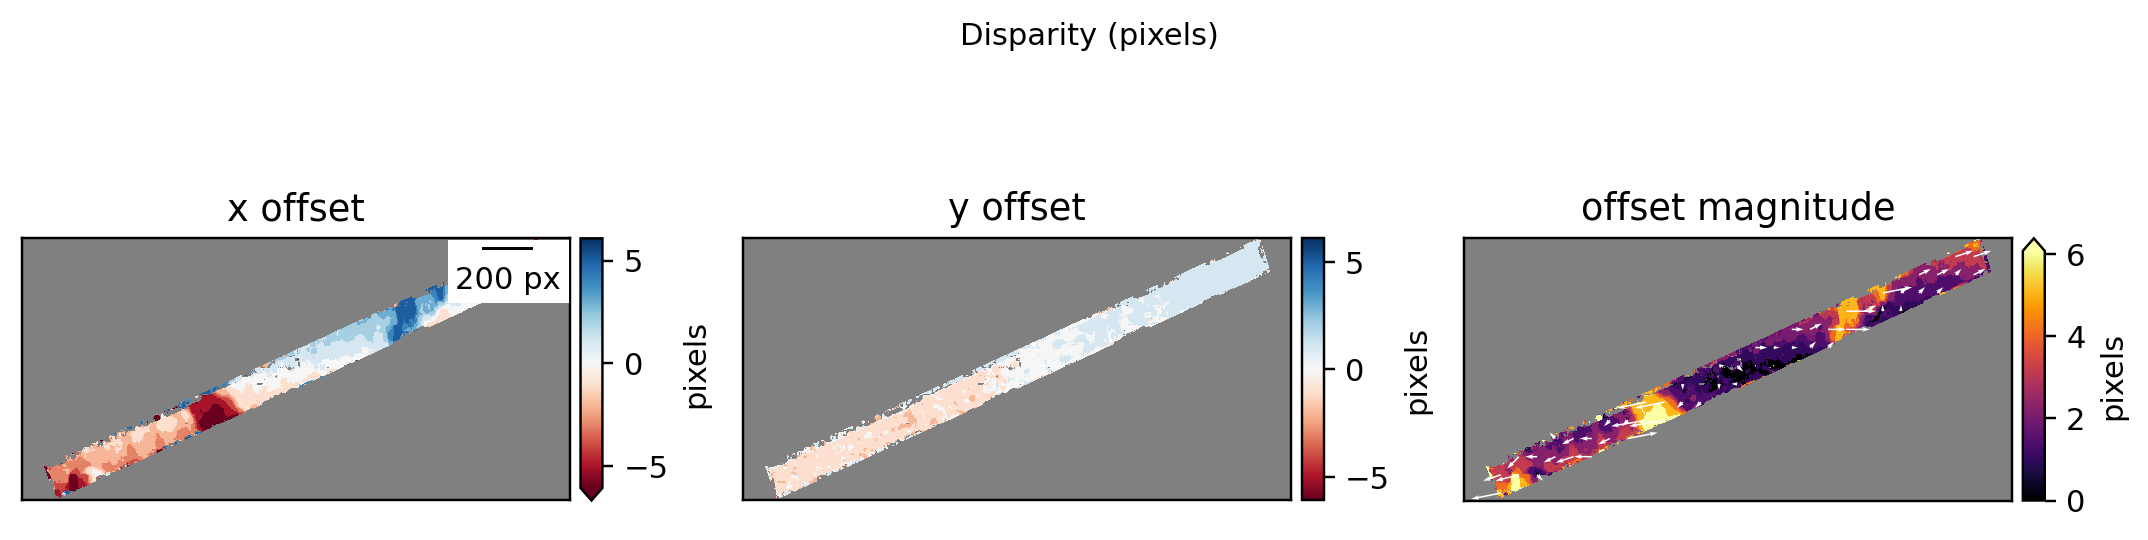

In [13]:
plotter.title = "Disparity (pixels)"

plotter.plot_disparity(
  unit="pixels",
  quiver=True,
)

Plotting DEM results. This can take a minute for large inputs.


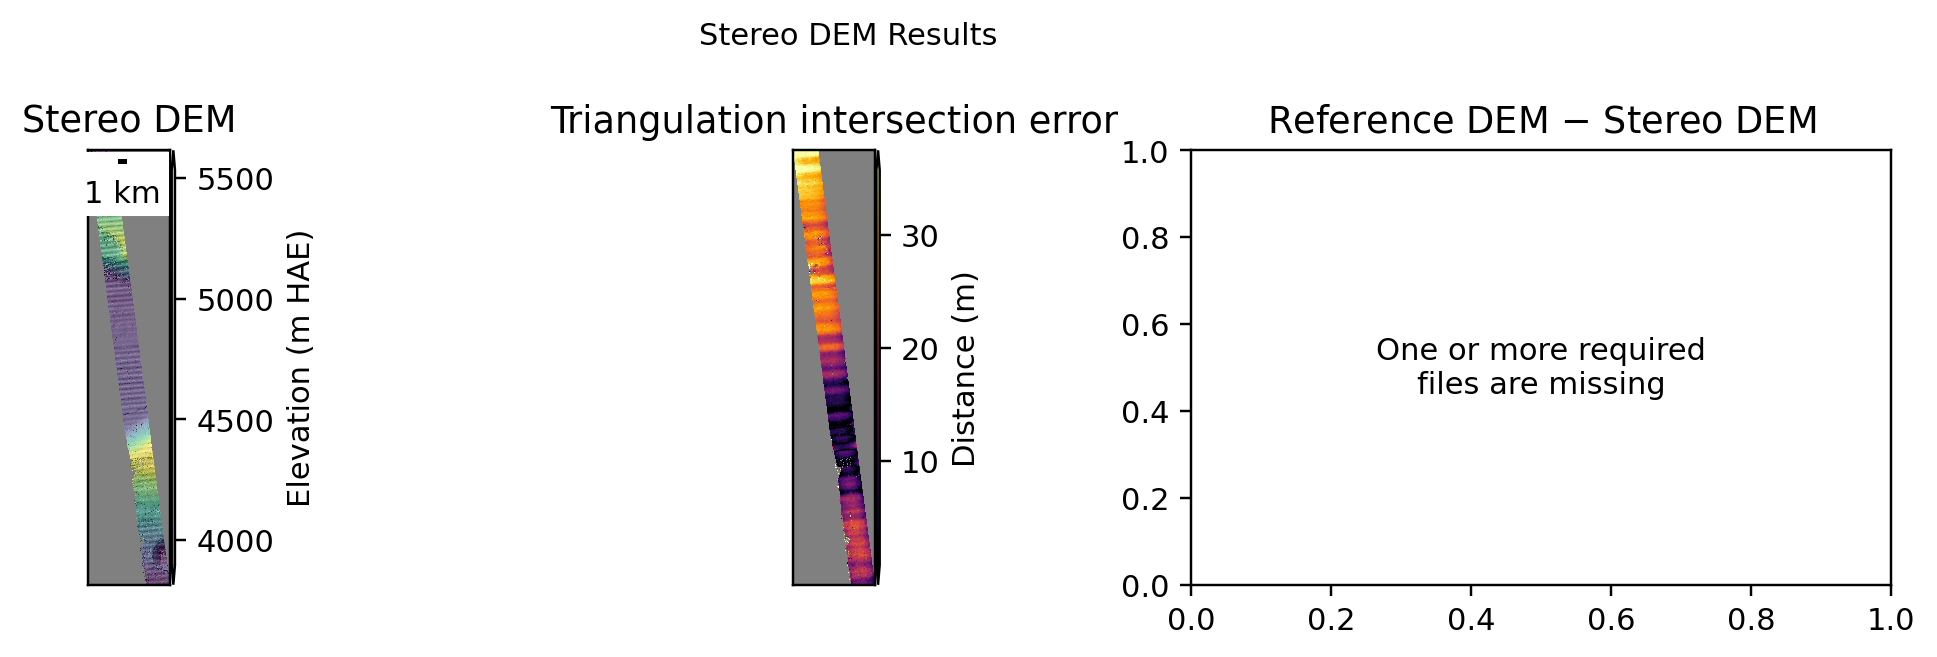

In [14]:
plotter.title = "Stereo DEM Results"

plotter.plot_dem_results()

### MOLA Altimetry Comparison

Compare the ASP DEM against Mars Orbiter Laser Altimeter (MOLA) altimetry data from the ODE Granular Data System (GDS).

#### Step 1: Request MOLA data

Use the `request_planetary_altimetry` CLI tool to submit a query. The tool auto-detects that this is a Mars DEM and submits a MOLA PEDR request:

```bash
request_planetary_altimetry \
  --dem result/output-DEM.tif \
  --email user@example.com
```

This saves an `altimetry_request_info.yml` alongside the DEM with the job metadata. You will receive an email when the data is ready.

#### Step 2: Download and unzip

Download the `.zip` from the link in the email and unzip it. The key file is `*_topo_csv.csv`.

#### Step 3: Load and compare

Pass the CSV to the `Altimetry` class (or use `asp_plot --altimetry_csv` for the full report):

In [15]:
from asp_plot.altimetry import Altimetry

dem_fn = f"{directory}/{stereo_directory}/output-DEM.tif"
mola_csv = f"{directory}/438125_mola/MolaPEDR_24N24N_263E263E_20260319T205257836_topo_csv.csv"

alt = Altimetry(directory=directory, dem_fn=dem_fn)
alt.load_planetary_csv(mola_csv)

Note: MOLA topography is referenced to the MOLA areoid. ASP DEMs use the IAU sphere. A systematic vertical offset may be present in dh values.
Loaded 1355 MOLA points


In [16]:
alt.planetary_to_dem_dh()
alt.planetary_points[["lon", "lat", "height", "dem_height", "altimetry_minus_dem"]].head(10)

Computed dh for 583 of 1355 points


,lon,lat,height,dem_height,altimetry_minus_dem
0,-96.98786,23.6173,6508.79,4058.577523,2450.212477
1,-96.98713,23.6223,6468.47,4144.054994,2324.415006
2,-96.96425,23.6253,6369.45,NaN,NaN
3,-97.00244,23.6289,6569.82,4183.725823,2386.094177
4,-96.96355,23.6304,6289.01,NaN,NaN
5,-97.01235,23.6330,6561.90,4159.270229,2402.629771
6,-97.00315,23.6340,6616.12,4201.983188,2414.136812
7,-97.01163,23.6380,6598.10,4233.017135,2365.082865
8,-97.00386,23.6391,6631.99,4258.245087,2373.744913
9,-96.98424,23.6426,6252.52,3890.744707,2361.775293


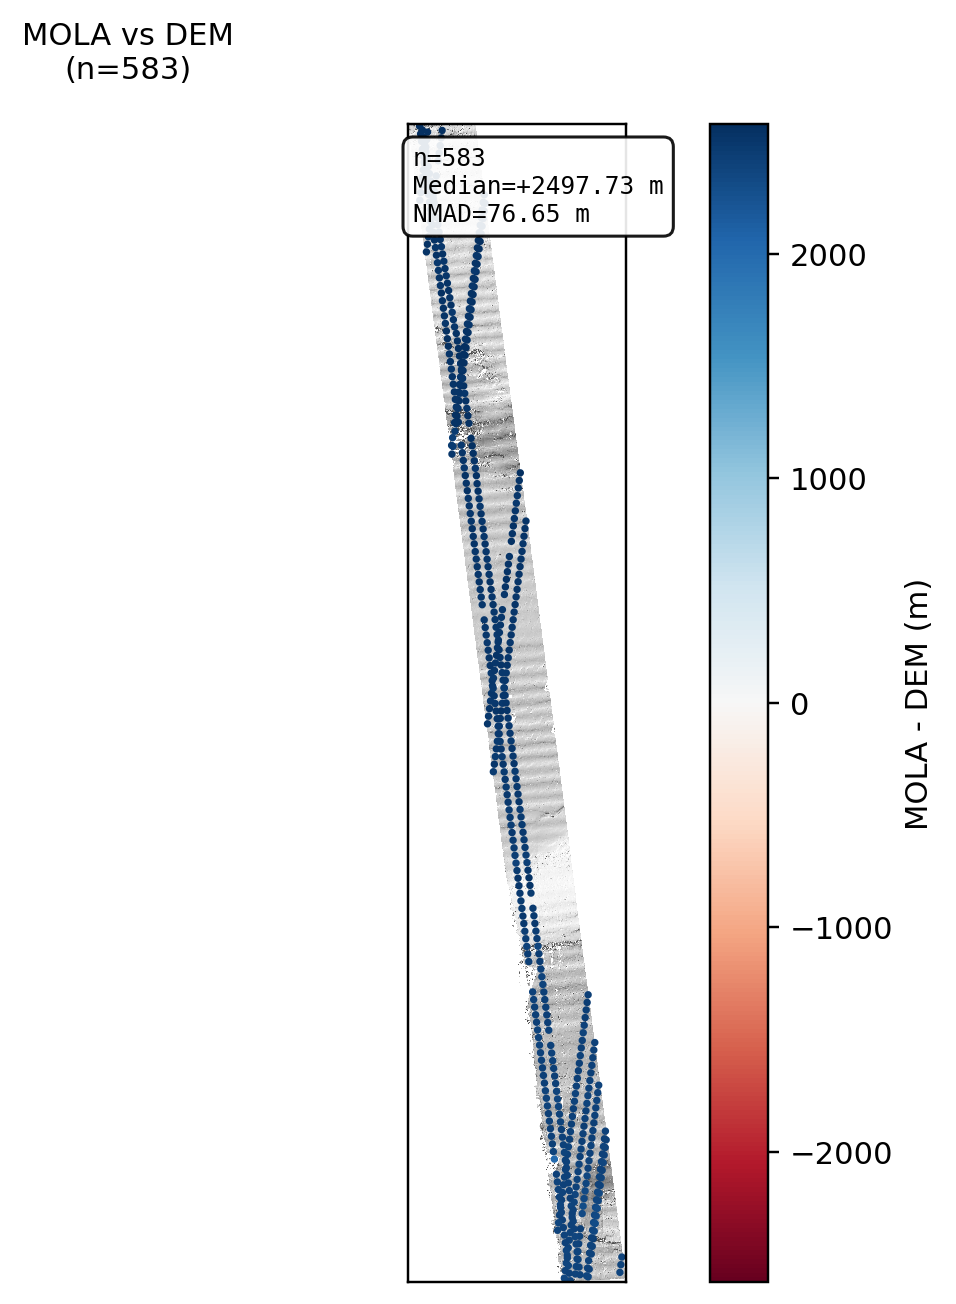

In [17]:
alt.mapview_plot_planetary_to_dem()

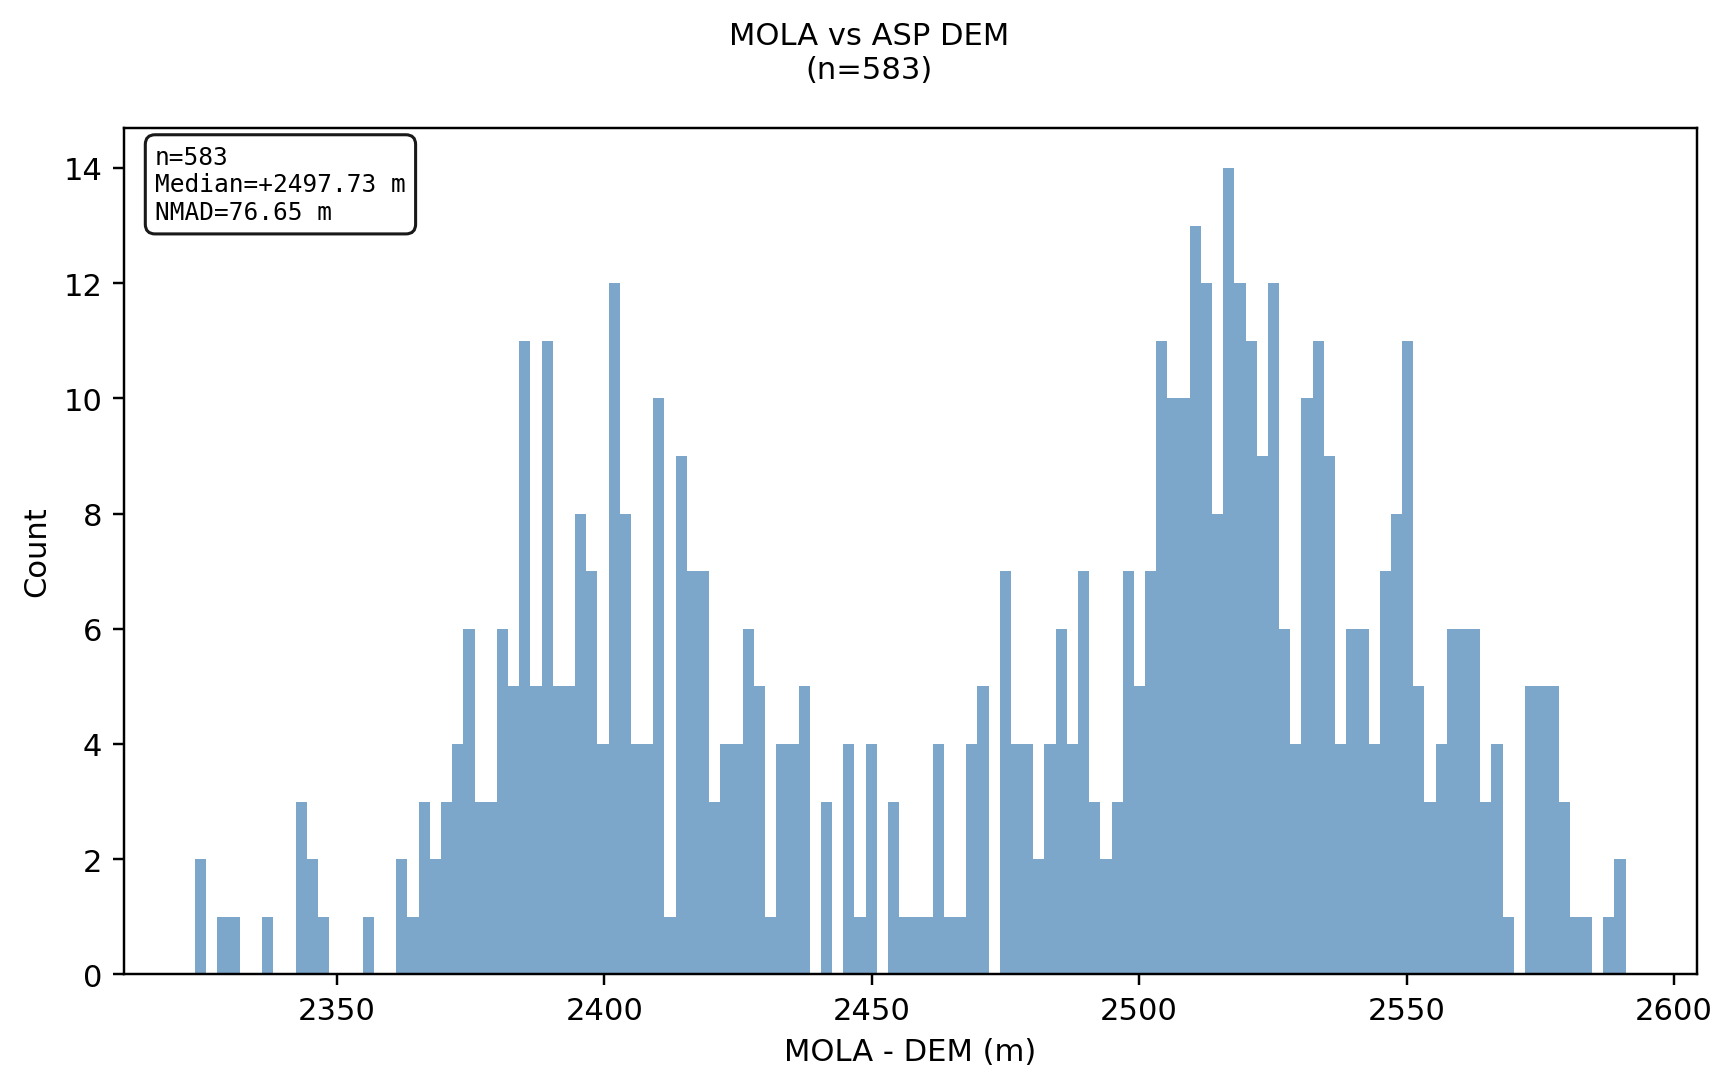

In [18]:
alt.histogram_planetary_to_dem()